In [1]:
import pandas as pd, numpy as np
import sys, os
import seaborn as sns
import matplotlib.pyplot as plt
try:
    CURRENT_FOLDER = os.path.dirname(__file__) # normal way
except NameError:
    CURRENT_FOLDER = globals()['_dh'][0] # jupyter notebook way
sys.path.append(os.path.join(CURRENT_FOLDER, "..", "..", "benchmark"))

import benchmark_one

from IPython.display import display

In [2]:


INCREMENTAL_ALGOS = {"CNNR", "CkNNR"}
BEST_STATE_ALGOS = {"EnergyCompress", "CNNR", "CkNNR"}
best_states = dict()

cb_learners = set()
for algo in set(benchmark_one.CB_LEARNERS):
    for classifier in set(benchmark_one.CLASSIFIERS):  
        for dataset in set(benchmark_one.DATASETS):
            try:
                sys.argv = [""] + [dataset] + ["-a", algo] + ["-c", classifier]
                args = benchmark_one.parse_args()
                results = benchmark_one.load_results(args=args)
                df = pd.DataFrame.from_records(results["records"])
                first_model = df.sort_values("CB_size", ascending=algo in INCREMENTAL_ALGOS).groupby("fold").head(1)
                max_model = df.sort_values("CB_size", ascending=False).groupby("fold").head(1)
                #best_model["compression_rate"] = 1. - (best_model["CB_size"].astype(float) / results["args"]["size_S"])
                if algo in BEST_STATE_ALGOS:
                    best_model = df.sort_values("test_accuracy", ascending=False).groupby("fold").head(1)
                else:
                    best_model = df[df["step"]==1].copy()
                print(sys.argv, len(best_model[["step", "test_accuracy"]]))
                #print(best_model[["step", "test_accuracy"]])

                best_model["compression_rate"] = best_model["CB_size"].astype(float) / results["args"]["size_S"]
                
                #best_initial = pd.concat({"best": best_model, "initial": first_model})
                best_model = best_model.rename({"test_accuracy": "Accuracy", "CB_size": "|CB|"}, axis=1)
                best_states[(args.dataset_name, args.classifier, args.algo,)] = best_model

                cb_learners.add(algo)

            except (FileNotFoundError, ValueError):
                pass

['', 'credit+approval', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'wine', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'lenses', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'lung+cancer', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'glass+identification', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'hepatitis', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'dermatology', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'zoo', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'breast+cancer+wisconsin+prognostic', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'liver+disorders', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'kaggle+pima+indian+diabetes', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'ionosphere', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'breast+cancer+wisconsin+diagnostic', '-a', 'EnergyCompress', 

In [3]:

best_states_df = pd.concat(best_states, axis=0).sort_index(level=0)
non_best_state_results_mask = best_states_df.index.to_series().apply(lambda x: x[2] not in BEST_STATE_ALGOS)
failed_runs_mask = non_best_state_results_mask & (best_states_df["compression_rate"] == 1)
failed_runs = best_states_df[failed_runs_mask]
print("involved compression algos")
print(failed_runs.index.to_frame()[2].value_counts())
print("involved prediction algos")
print(failed_runs.index.to_frame()[1].value_counts())


best_states_df_no_fails = best_states_df[~failed_runs_mask]
complete = (best_states_df_no_fails.index.to_frame()[[0,1,2]].aggregate(tuple, axis=1).value_counts() == 10)
complete_list = complete.index.to_list()
complete_mask = best_states_df_no_fails.index.to_frame()[[0,1,2]].aggregate(tuple, axis=1).apply(lambda x: x in complete_list)
#best_states_df_no_fails.groupby(best_states_df_no_fails.index.to_frame()[[0,1,2]].aggregate(tuple, axis=1))
best_states_df_no_fails_complete = best_states_df_no_fails[complete_mask]
best_states_df_no_fails_complete.index = pd.MultiIndex.from_frame(best_states_df_no_fails_complete.reset_index()[["level_0","level_1","level_2","fold"]])

involved compression algos
egdis    24
cnn      21
lssm     12
enn       6
Name: 2, dtype: int64
involved prediction algos
CoAT          11
CtCoAT        11
kNN           11
SVM-linear    10
SVM-poly      10
SVM-rbf       10
Name: 1, dtype: int64


In [4]:
best_states_df_no_fails_complete

ref_gold_labels  \
level_0       level_1 level_2 fold                                                      
Balance Scale CoAT    CNNR    0     [1, 2, 0, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, ...   
                              1     [2, 0, 2, 1, 2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 1, ...   
                              2     [1, 2, 0, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, ...   
                              3     [1, 0, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, ...   
                              4     [1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 0, 1, ...   
...                                                                               ...   
Zoo           kNN     xldis   5     [3, 5, 1, 0, 6, 0, 0, 0, 0, 2, 0, 0, 0, 5, 3, ...   
                              6     [0, 1, 0, 5, 3, 0, 1, 3, 2, 6, 3, 6, 0, 0, 0, ...   
                              7     [6, 3, 0, 1, 3, 2, 0, 5, 0, 0, 3, 0, 0, 0, 3, ...   
                              8     [3, 6, 0, 3, 0, 0, 6, 6, 0, 0, 3, 6, 1, 0, 0, ...   
                              9     [6, 0, 0, 3, 5, 0, 0, 3, 4, 0, 0, 0, 1, 5, 0, ...   

                                                                      ref_pred_probas  \
level_0       level_1 level_2 fold                                                      
Balance Scale CoAT    CNNR    0     [[1.0, 7.445620940050319e-119], [4.78089288388...   
                              1     [[1.0, 4.1863939993042314e-51, 1.0530617357553...   
                              2     [[0.9933071490757153, 0.006692850924284856], [...   
                              3     [[1.9503933001302485e-65, 1.0, 4.6260831123710...   
                              4     [[3.720075976020836e-44, 5.521082277028533e-42...   
...                                                                               ...   
Zoo           kNN     xldis   5     [[0.14285714285714285, 0.14285714285714285, 0....   
                              6     [[0.16431513114008345, 0.1424411557798912, 0.1...   
                              7     [[0.14285714285714285, 0.14285714285714285, 0....   
                              8     [[0.16431513114008345, 0.1424411557798912, 0.1...   
                              9     [[0.14285714285714285, 0.14285714285714285, 0....   

                                                                      ref_pred_labels  \
level_0       level_1 level_2 fold                                                      
Balance Scale CoAT    CNNR    0     [1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, ...   
                              1     [0, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 2, 1, 0, 0, ...   
                              2     [1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, ...   
                              3     [1, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, 2, ...   
                              4     [2, 0, 2, 0, 0, 0, 2, 0, 1, 1, 1, 0, 2, 0, 1, ...   
...                                                                               ...   
Zoo           kNN     xldis   5     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
                              6     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
                              7     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
                              8     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
                              9     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                    ref_accuracy  \
level_0       level_1 level_2 fold                 
Balance Scale CoAT    CNNR    0             0.72   
                              1             0.58   
                              2             0.76   
                              3             0.60   
                              4             0.64   
...                                          ...   
Zoo           kNN     xldis   5             0.60   
                              6             0.30   
                              7             0.35   
                        

In [5]:
best_states_df_no_fails_complete_ = best_states_df_no_fails_complete.reset_index(names=["level_0","level_1","level_2","level_3"])#["Accuracy"].reset_index()
#best_states_df_no_fails_complete_["level_3"] = best_states_df_no_fails_complete["fold"]

#best_states_df_no_fails_complete_

SCORE = "Accuracy"
# ranks on level_1 (prediction algo)
best_states_df_no_fails_complete_ranks_lv_1 = best_states_df_no_fails_complete_.pivot(index=["level_0", "level_2", "level_3"], columns="level_1", values=SCORE).rank(axis=1, method="min", ascending=False) #method="dense"
x = best_states_df_no_fails_complete_ranks_lv_1.melt(value_vars=best_states_df_no_fails_complete_ranks_lv_1.columns, var_name="level_1", value_name="level_1_rank", ignore_index=False)
x.index = pd.MultiIndex.from_frame(x.reset_index()[["level_0","level_1","level_2","level_3"]])
best_states_df_no_fails_complete["level_1_rank"] = x["level_1_rank"]

best_states_df_no_fails_complete["level_1_rank"] = best_states_df_no_fails_complete["level_1_rank"].astype(int)

# ranks on level_2 (compression algo)
best_states_df_no_fails_complete_ranks_lv_2 = best_states_df_no_fails_complete_.pivot(index=["level_0", "level_1", "level_3"], columns="level_2", values=SCORE).rank(axis=1, method="min", ascending=False) #method="dense"
x = best_states_df_no_fails_complete_ranks_lv_2.melt(value_vars=best_states_df_no_fails_complete_ranks_lv_2.columns, var_name="level_2", value_name="level_2_rank", ignore_index=False)
x.index = pd.MultiIndex.from_frame(x.reset_index()[["level_0","level_1","level_2","level_3"]])
best_states_df_no_fails_complete["level_2_rank"] = x["level_2_rank"]

best_states_df_no_fails_complete["level_2_rank"] = best_states_df_no_fails_complete["level_2_rank"].astype(int)
best_states_df_no_fails_complete.index = best_states_df_no_fails_complete.index.set_names( "level_3", level=3)

In [6]:
lv_0 = best_states_df_no_fails_complete.index.get_level_values(0).unique()
lv_1 = best_states_df_no_fails_complete.index.get_level_values(1).unique()
lv_2 = best_states_df_no_fails_complete.index.get_level_values(2).unique()
best_states_df_no_fails_complete[["level_1_rank", "level_2_rank"]], lv_0, lv_1, lv_2

(                                       level_1_rank  level_2_rank
 level_0       level_1 level_2 level_3                            
 Balance Scale CoAT    CNNR    0                   6             5
                               1                   6            10
                               2                   5             1
                               3                   6             8
                               4                   6             8
 ...                                             ...           ...
 Zoo           kNN     xldis   5                   6            13
                               6                   6            13
                               7                   6            13
                               8                   6            13
                               9                   6            11
 
 [13941 rows x 2 columns],
 Index(['Balance Scale', 'Breast Cancer Wisconsin Diagnostic',
        'Breast Cancer Wisconsin Prog

# ranking summary for accuracy

<Axes: xlabel='level_0', ylabel='level_1_rank'>

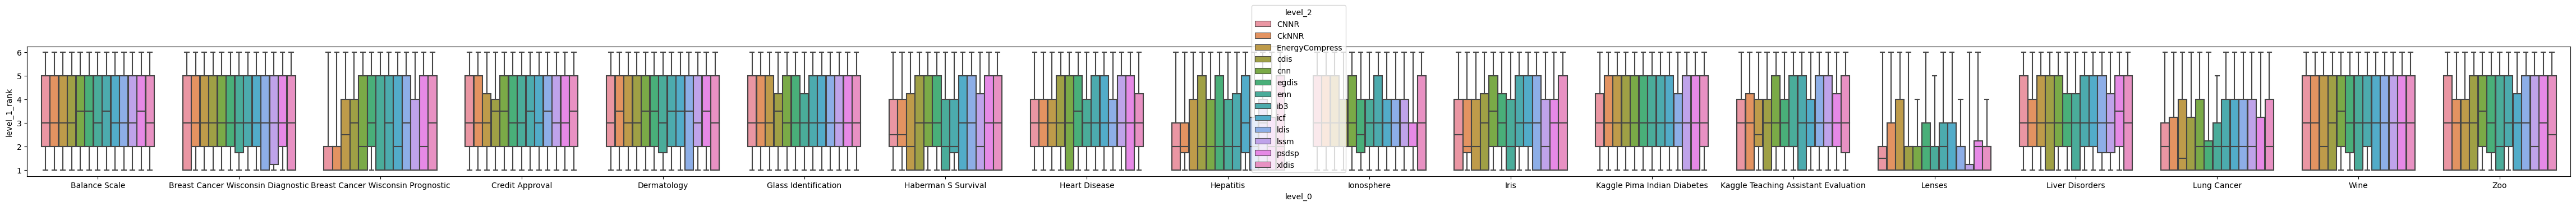

In [7]:
plt.figure(figsize=(len(lv_0)*len(lv_2)*.25, 3))
sns.boxplot(best_states_df_no_fails_complete.reset_index(), x="level_0", y="level_1_rank", hue="level_2", whis=(0, 100))

<Axes: xlabel='level_0', ylabel='level_2_rank'>

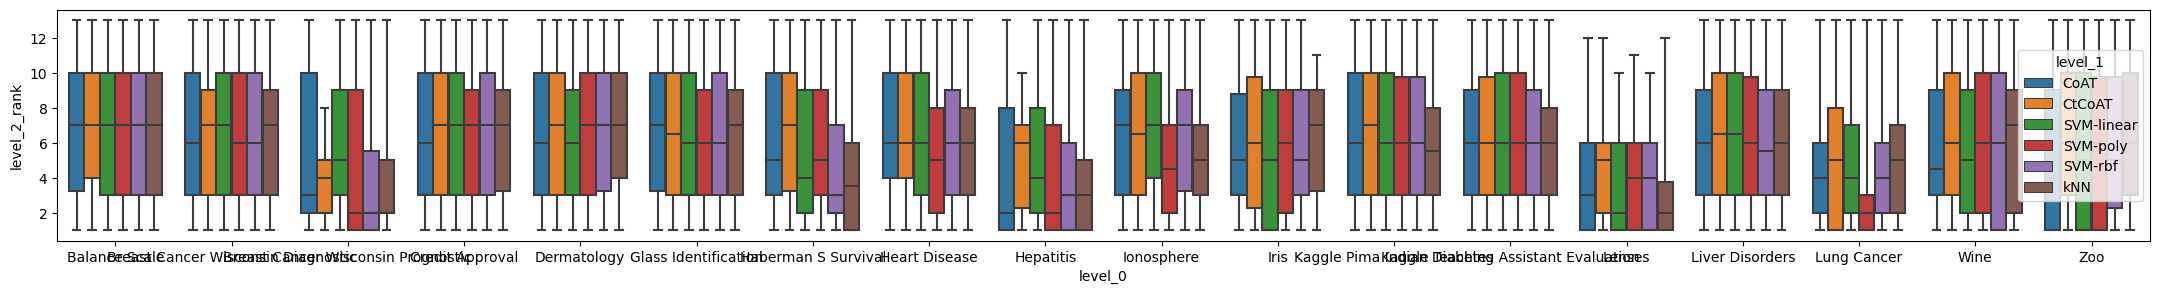

In [8]:
plt.figure(figsize=(len(lv_0)*len(lv_1)*.25, 3))
sns.boxplot(best_states_df_no_fails_complete.reset_index(), x="level_0", y="level_2_rank", hue="level_1", whis=(0, 100))

# Ranking violin

In [9]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    return


In [10]:
%%skip

plt.figure(figsize=(len(lv_0), 3))
d = best_states_df_no_fails_complete.reset_index()
d["level_1_rank"] = -d["level_1_rank"]
g = sns.violinplot(d, x="level_2", y="level_1_rank", whis=(0, 100))
g.set_ylim([d["level_1_rank"].min(),d["level_1_rank"].max()])
g.get_yaxis().set_major_formatter(lambda x, _: int(abs(x)))

In [11]:
%%skip

plt.figure(figsize=(len(lv_1), 3))
sns.violinplot(best_states_df_no_fails_complete.reset_index(), x="level_1", y="level_2_rank", whis=(0, 100))

In [12]:
%%skip

plt.figure(figsize=(len(lv_0), 3))
d = best_states_df_no_fails_complete.reset_index()
g = sns.barplot(d, x="level_2", y="level_1_rank", errorbar=("pi", 100))

## Accuracy box plots

In [13]:
import numpy as np
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
order = d.groupby(["Dataset", "level_2"])["Accuracy"].median().reset_index().groupby(["Dataset"])["Accuracy"].aggregate(list).apply( lambda x: np.argsort(x)[::-1].argsort())
order = d["level_2"].unique()[np.argsort([np.mean(y) for y in zip(*order)])]
order

array(['EnergyCompress', 'lssm', 'CkNNR', 'CNNR', 'enn', 'icf', 'cnn',
       'psdsp', 'xldis', 'ib3', 'ldis', 'egdis', 'cdis'], dtype=object)

<Figure size 5850x300 with 0 Axes>

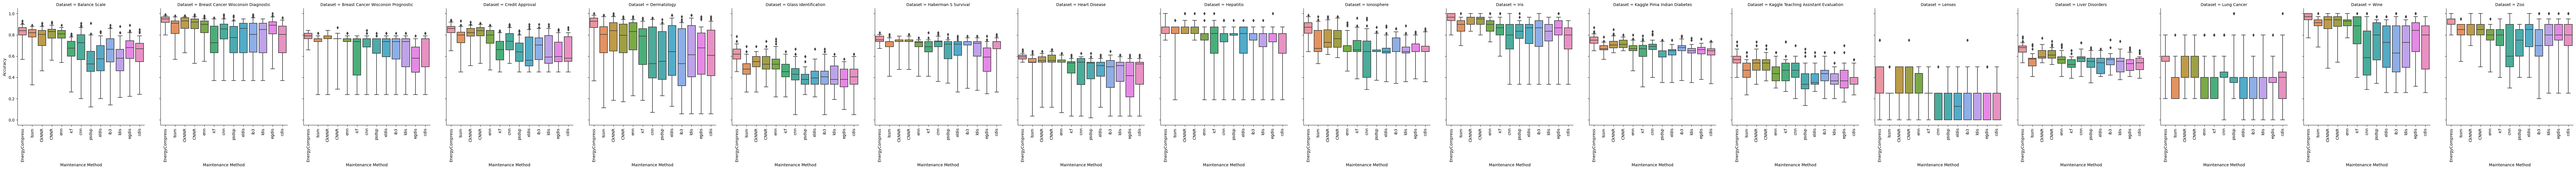

In [14]:
plt.figure(figsize=(len(lv_0)*len(lv_2)*.25, 3))
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
g = sns.catplot(d, x="level_2", y="Accuracy", whis=(0, 95), kind="box", col="Dataset", order=order)
g.set_axis_labels(x_var="Maintenance Method")
for axes in g.axes.flat:
    _ = axes.set_xticklabels(axes.get_xticklabels(), rotation=90)

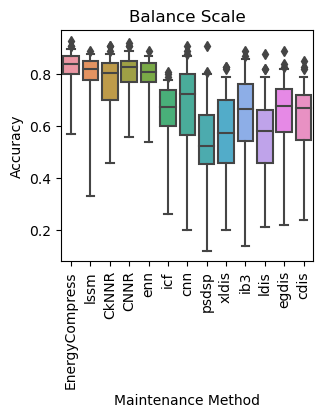

<Figure size 640x480 with 0 Axes>

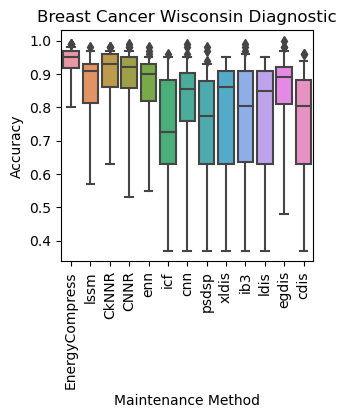

<Figure size 640x480 with 0 Axes>

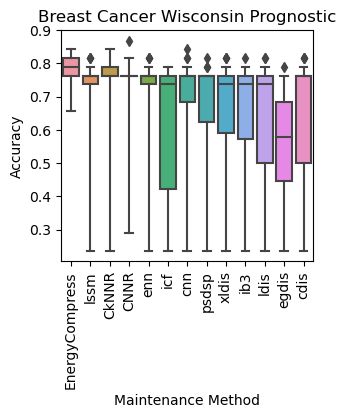

<Figure size 640x480 with 0 Axes>

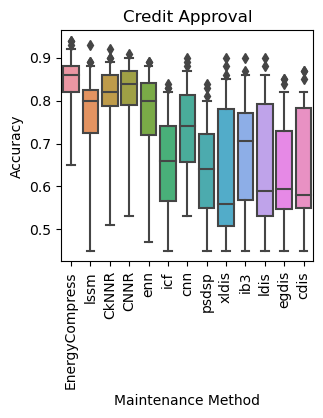

<Figure size 640x480 with 0 Axes>

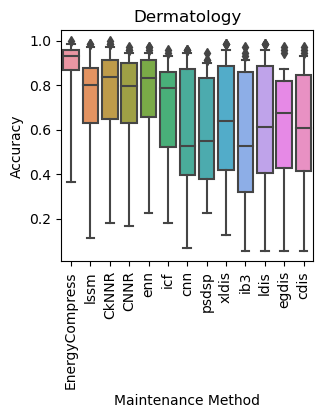

<Figure size 640x480 with 0 Axes>

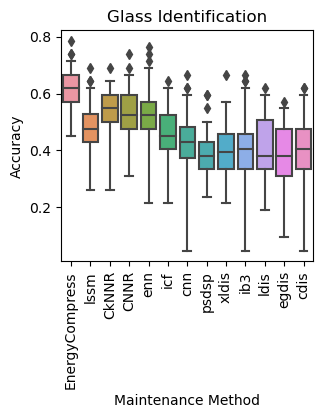

<Figure size 640x480 with 0 Axes>

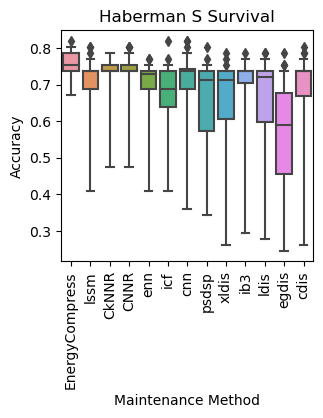

<Figure size 640x480 with 0 Axes>

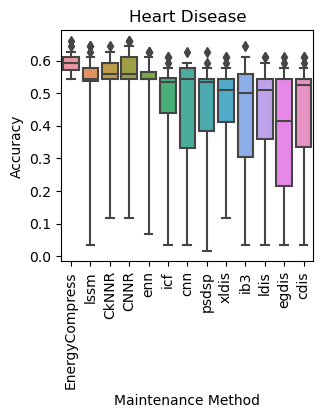

<Figure size 640x480 with 0 Axes>

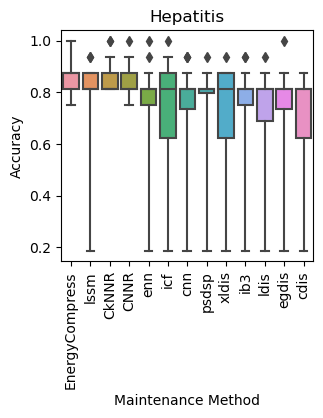

<Figure size 640x480 with 0 Axes>

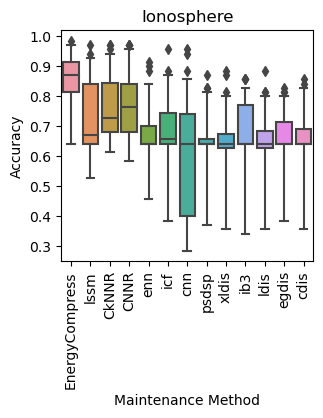

<Figure size 640x480 with 0 Axes>

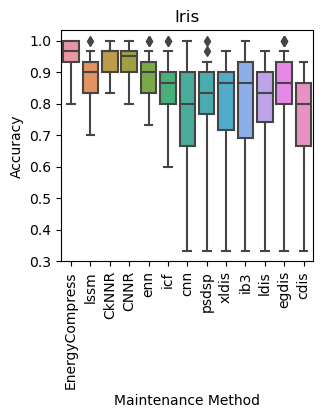

<Figure size 640x480 with 0 Axes>

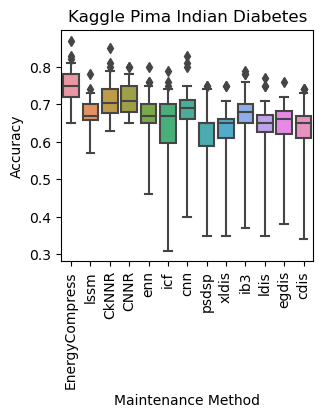

<Figure size 640x480 with 0 Axes>

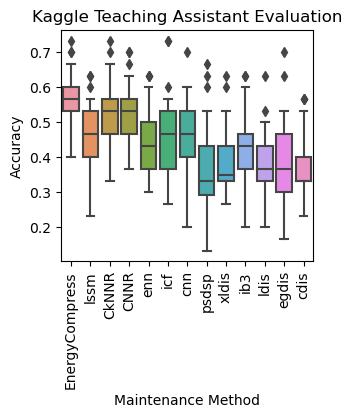

<Figure size 640x480 with 0 Axes>

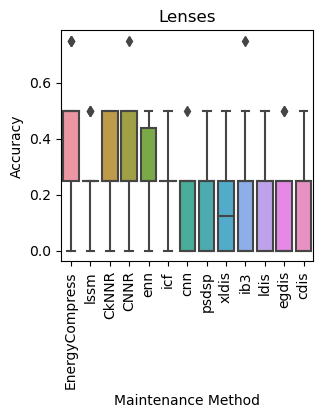

<Figure size 640x480 with 0 Axes>

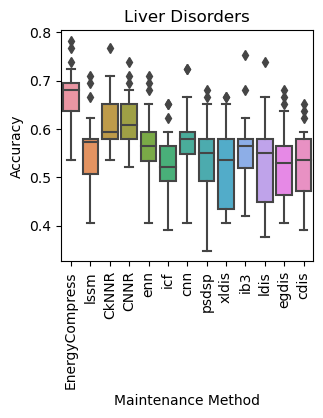

<Figure size 640x480 with 0 Axes>

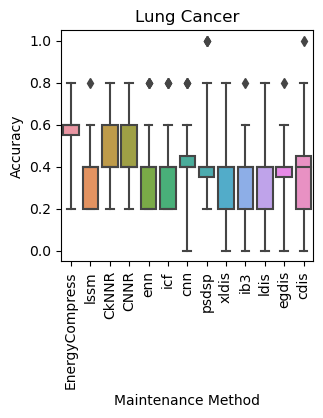

<Figure size 640x480 with 0 Axes>

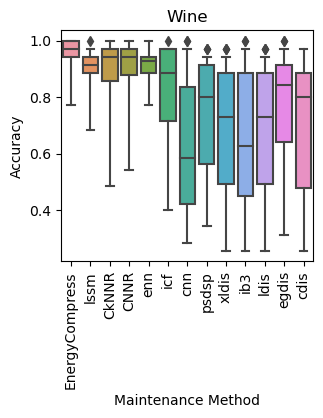

<Figure size 640x480 with 0 Axes>

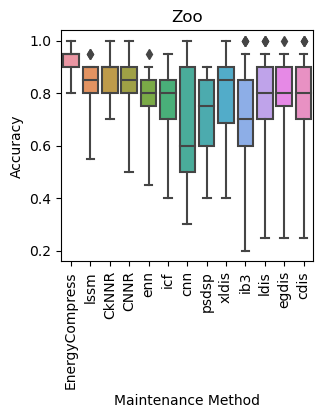

<Figure size 640x480 with 0 Axes>

In [15]:
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
os.makedirs("v0.2/plots", exist_ok=True)
for dataset in d["Dataset"].unique():
    plt.figure(figsize=(len(lv_2)*.25, 3))
    g = sns.boxplot(d[d["Dataset"]==dataset], x="level_2", y="Accuracy", whis=(0, 95), order=order)
    g.set_xlabel("Maintenance Method")
    g.set_xticklabels(g.get_xticklabels(), rotation=90)
    plt.title(dataset)
    os.makedirs(f"v0.2/plots/{dataset}", exist_ok=True)
    plt.savefig(f"v0.2/plots/{dataset}/acc-VS-maintainer-all-clf.png", bbox_inches="tight")
    plt.show()
    plt.clf()

In [16]:
%%skip

plt.figure(figsize=(len(lv_0)*len(lv_1)*.25, 3))
sns.boxplot(best_states_df_no_fails_complete.reset_index(), x="level_0", y="Accuracy", hue="level_1", whis=(0, 95))

In [17]:
import numpy as np
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
order1 = d.groupby(["Dataset", "level_1"])["Accuracy"].median().reset_index().groupby(["Dataset"])["Accuracy"].aggregate(list).apply( lambda x: np.argsort(x)[::-1].argsort())
order1 = d["level_1"].unique()[np.argsort([np.mean(y) for y in zip(*order1)])]
order1

array(['SVM-rbf', 'SVM-linear', 'kNN', 'CoAT', 'SVM-poly', 'CtCoAT'],
      dtype=object)

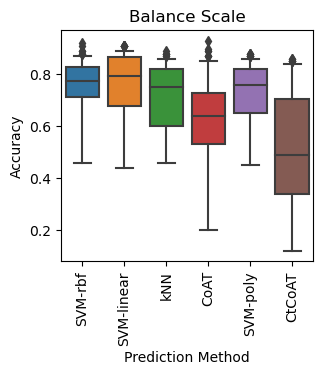

<Figure size 640x480 with 0 Axes>

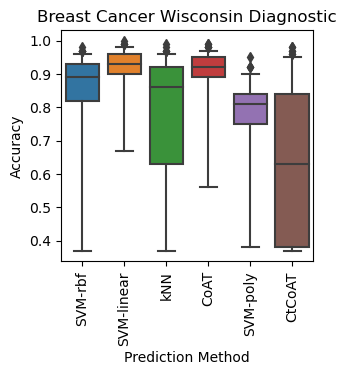

<Figure size 640x480 with 0 Axes>

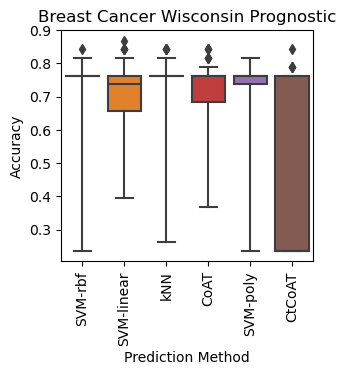

<Figure size 640x480 with 0 Axes>

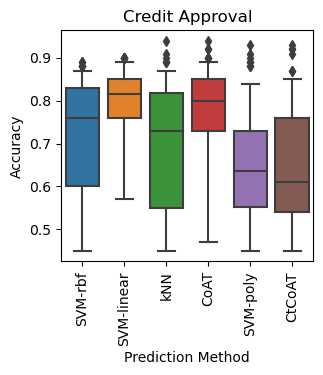

<Figure size 640x480 with 0 Axes>

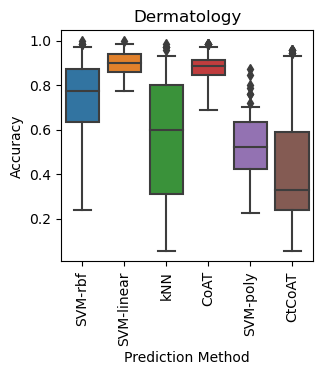

<Figure size 640x480 with 0 Axes>

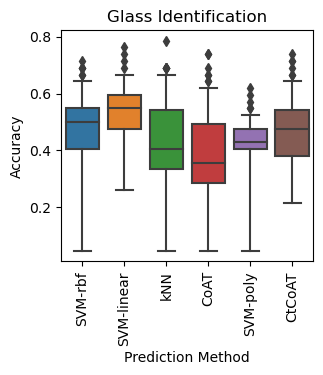

<Figure size 640x480 with 0 Axes>

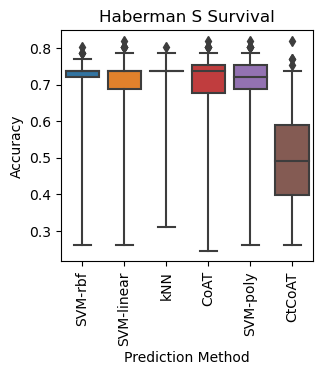

<Figure size 640x480 with 0 Axes>

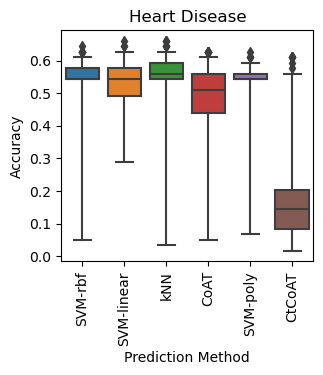

<Figure size 640x480 with 0 Axes>

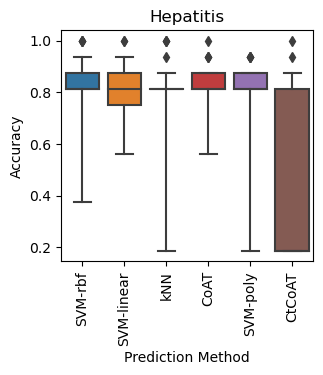

<Figure size 640x480 with 0 Axes>

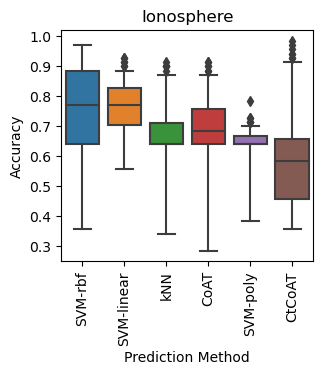

<Figure size 640x480 with 0 Axes>

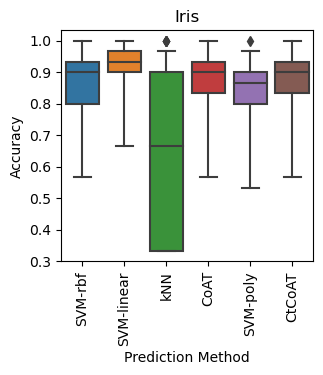

<Figure size 640x480 with 0 Axes>

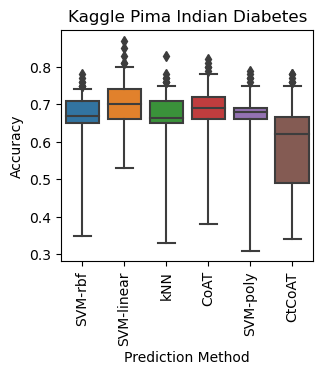

<Figure size 640x480 with 0 Axes>

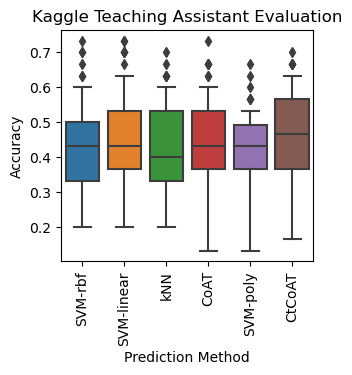

<Figure size 640x480 with 0 Axes>

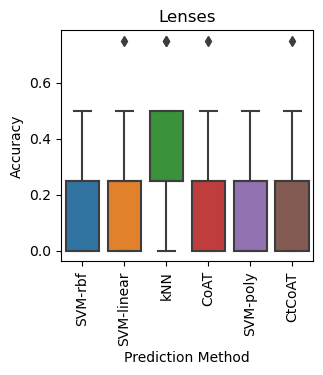

<Figure size 640x480 with 0 Axes>

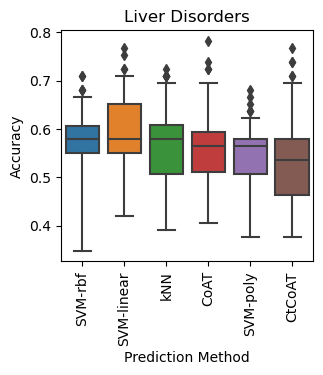

<Figure size 640x480 with 0 Axes>

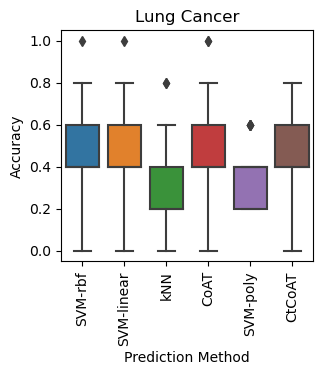

<Figure size 640x480 with 0 Axes>

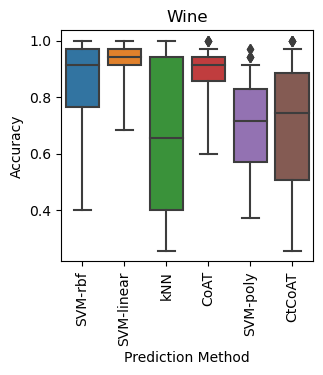

<Figure size 640x480 with 0 Axes>

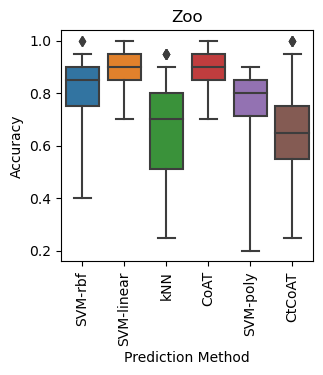

<Figure size 640x480 with 0 Axes>

In [18]:
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
for dataset in d["Dataset"].unique():
    plt.figure(figsize=(len(lv_2)*.25, 3))
    g = sns.boxplot(d[d["Dataset"]==dataset], x="level_1", y="Accuracy", whis=(0, 95), order=order1)
    g.set_xlabel("Prediction Method")
    g.set_xticklabels(g.get_xticklabels(), rotation=90)
    plt.title(dataset)
    plt.savefig(f"v0.2/plots/{dataset}/acc-VS-clf-all-maintainer.png", bbox_inches="tight")
    plt.show()
    plt.clf()

###

In [19]:
best_states_df_no_fails_complete_ = best_states_df_no_fails_complete.reset_index(names=["level_0","level_1","level_2","level_3"])#["Accuracy"].reset_index()
#best_states_df_no_fails_complete_["level_3"] = best_states_df_no_fails_complete["fold"]

#best_states_df_no_fails_complete_

SCORE = "compression_rate"
# ranks on level_1 (prediction algo)
best_states_df_no_fails_complete_ranks_lv_1 = best_states_df_no_fails_complete_.pivot(index=["level_0", "level_2", "level_3"], columns="level_1", values=SCORE).rank(axis=1, method="min", ascending=False) #method="dense"
x = best_states_df_no_fails_complete_ranks_lv_1.melt(value_vars=best_states_df_no_fails_complete_ranks_lv_1.columns, var_name="level_1", value_name="level_1_rank", ignore_index=False)
x.index = pd.MultiIndex.from_frame(x.reset_index()[["level_0","level_1","level_2","level_3"]])
best_states_df_no_fails_complete["level_1_rank"] = x["level_1_rank"]

best_states_df_no_fails_complete["level_1_rank"] = best_states_df_no_fails_complete["level_1_rank"].astype(int)

# ranks on level_2 (compression algo)
best_states_df_no_fails_complete_ranks_lv_2 = best_states_df_no_fails_complete_.pivot(index=["level_0", "level_1", "level_3"], columns="level_2", values=SCORE).rank(axis=1, method="min", ascending=False) #method="dense"
x = best_states_df_no_fails_complete_ranks_lv_2.melt(value_vars=best_states_df_no_fails_complete_ranks_lv_2.columns, var_name="level_2", value_name="level_2_rank", ignore_index=False)
x.index = pd.MultiIndex.from_frame(x.reset_index()[["level_0","level_1","level_2","level_3"]])
best_states_df_no_fails_complete["level_2_rank"] = x["level_2_rank"]

best_states_df_no_fails_complete["level_2_rank"] = best_states_df_no_fails_complete["level_2_rank"].astype(int)
best_states_df_no_fails_complete.index = best_states_df_no_fails_complete.index.set_names( "level_3", level=3)

import numpy as np
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
order = d.groupby(["Dataset", "level_2"])[SCORE].median().reset_index().groupby(["Dataset"])[SCORE].aggregate(list).apply( lambda x: np.argsort(x)[::-1].argsort())
order = d["level_2"].unique()[np.argsort([np.mean(y) for y in zip(*order)])]
order

import numpy as np
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
order1 = d.groupby(["Dataset", "level_1"])[SCORE].median().reset_index().groupby(["Dataset"])[SCORE].aggregate(list).apply( lambda x: np.argsort(x)[::-1].argsort())
order1 = d["level_1"].unique()[np.argsort([np.mean(y) for y in zip(*order1)])]
order1

array(['SVM-rbf', 'SVM-poly', 'SVM-linear', 'kNN', 'CtCoAT', 'CoAT'],
      dtype=object)

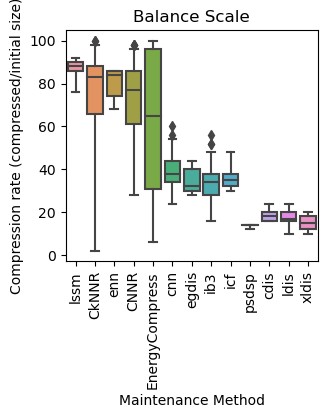

<Figure size 640x480 with 0 Axes>

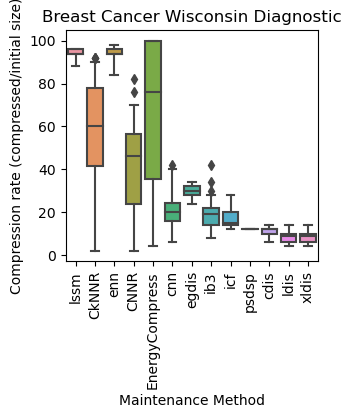

<Figure size 640x480 with 0 Axes>

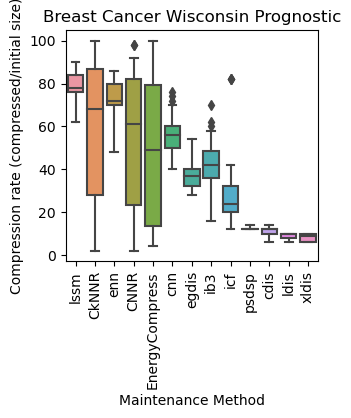

<Figure size 640x480 with 0 Axes>

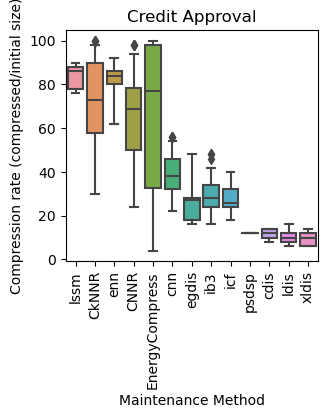

<Figure size 640x480 with 0 Axes>

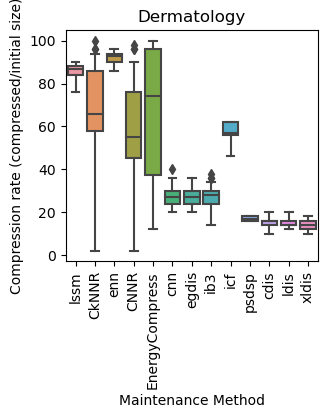

<Figure size 640x480 with 0 Axes>

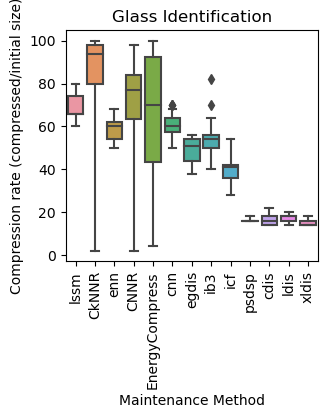

<Figure size 640x480 with 0 Axes>

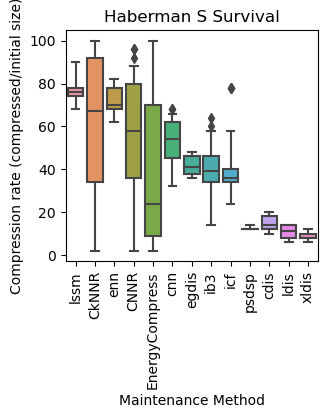

<Figure size 640x480 with 0 Axes>

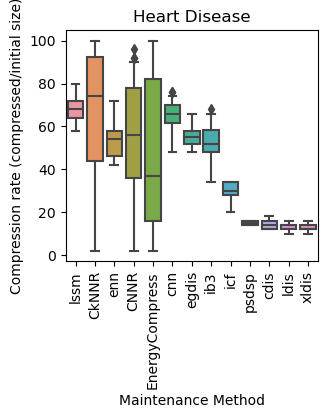

<Figure size 640x480 with 0 Axes>

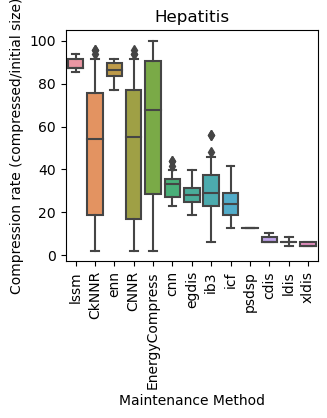

<Figure size 640x480 with 0 Axes>

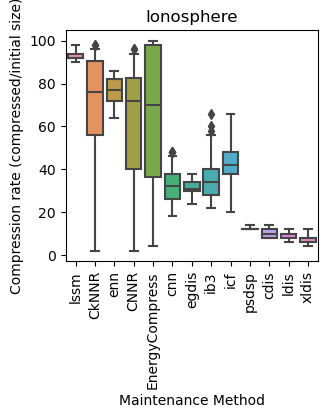

<Figure size 640x480 with 0 Axes>

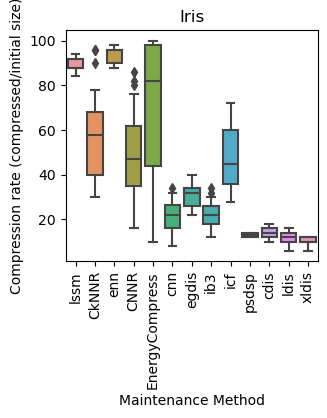

<Figure size 640x480 with 0 Axes>

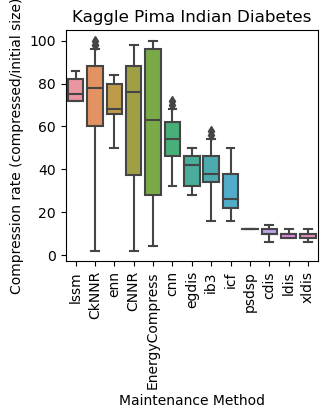

<Figure size 640x480 with 0 Axes>

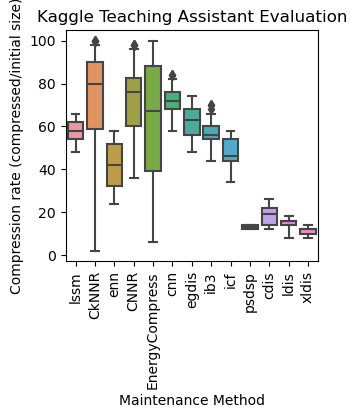

<Figure size 640x480 with 0 Axes>

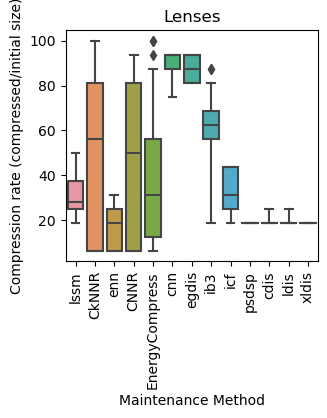

<Figure size 640x480 with 0 Axes>

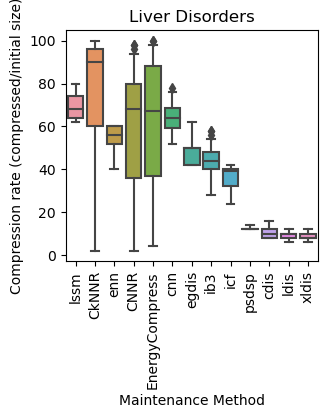

<Figure size 640x480 with 0 Axes>

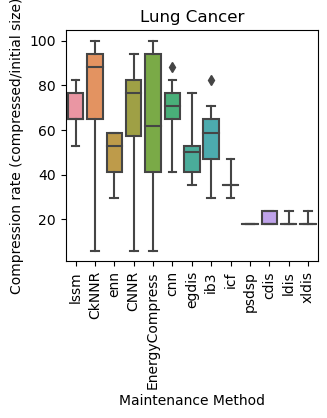

<Figure size 640x480 with 0 Axes>

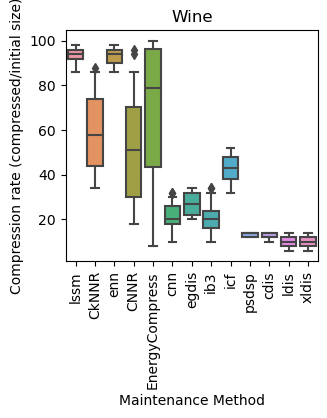

<Figure size 640x480 with 0 Axes>

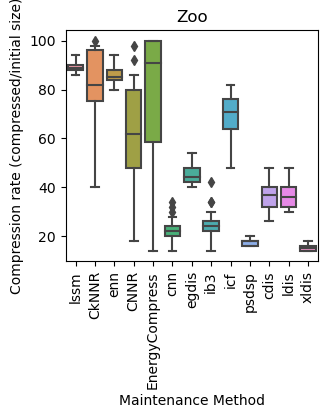

<Figure size 640x480 with 0 Axes>

In [22]:
d = best_states_df_no_fails_complete.reset_index()
d["Dataset"] = d["level_0"]
d["compression_rate"] = d["compression_rate"]*100
os.makedirs("v0.2/plots", exist_ok=True)
for dataset in d["Dataset"].unique():
    plt.figure(figsize=(len(lv_2)*.25, 3))
    g = sns.boxplot(d[d["Dataset"]==dataset], x="level_2", y="compression_rate", whis=(0, 95), order=order)
    g.set_ylabel("Compression rate (compressed/initial size)")
    g.set_xlabel("Maintenance Method")
    g.set_xticklabels(g.get_xticklabels(), rotation=90)
    plt.title(dataset)
    plt.savefig(f"v0.2/plots/{dataset}/comp-VS-maintainer-all-clf.png", bbox_inches="tight")
    plt.show()
    plt.clf()

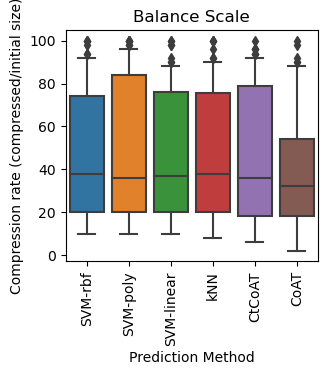

<Figure size 640x480 with 0 Axes>

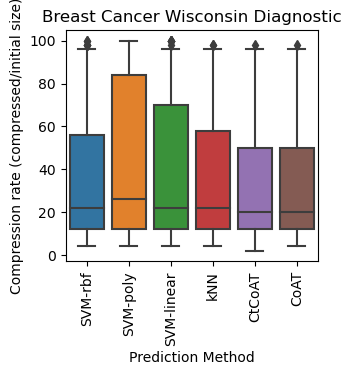

<Figure size 640x480 with 0 Axes>

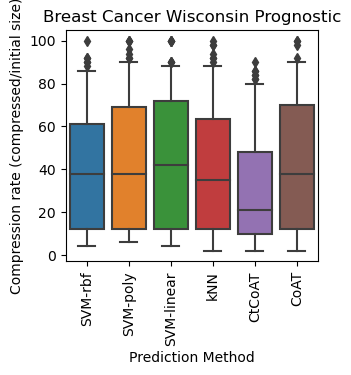

<Figure size 640x480 with 0 Axes>

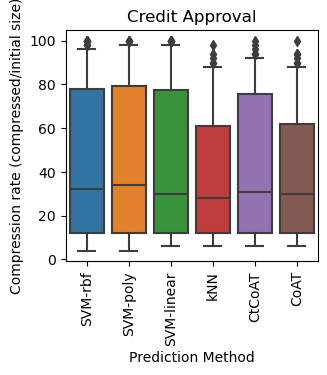

<Figure size 640x480 with 0 Axes>

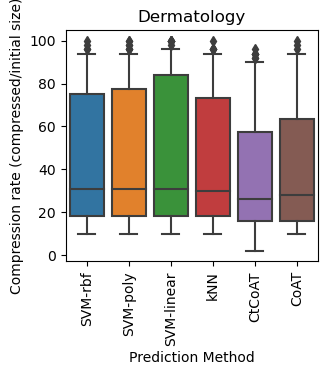

<Figure size 640x480 with 0 Axes>

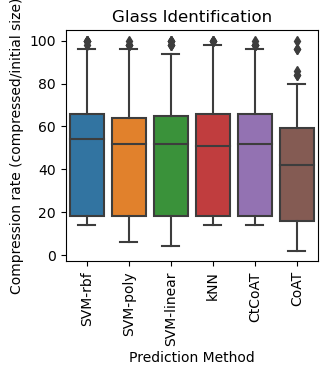

<Figure size 640x480 with 0 Axes>

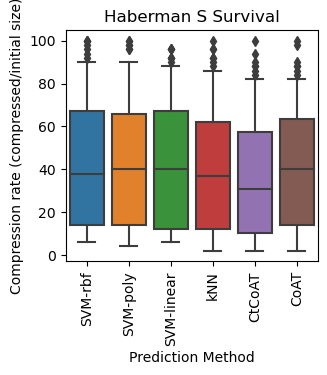

<Figure size 640x480 with 0 Axes>

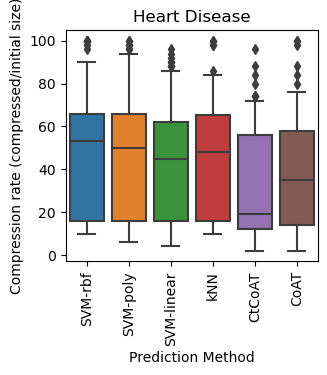

<Figure size 640x480 with 0 Axes>

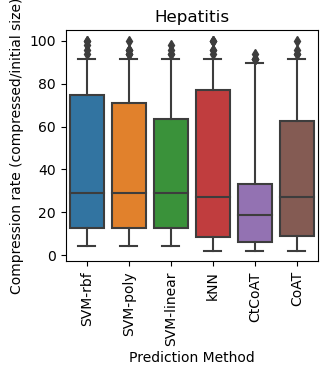

<Figure size 640x480 with 0 Axes>

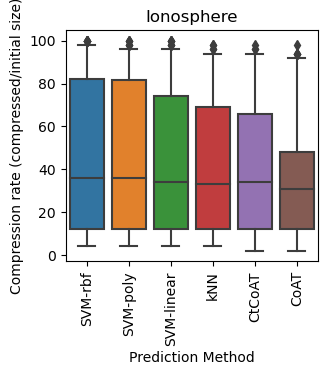

<Figure size 640x480 with 0 Axes>

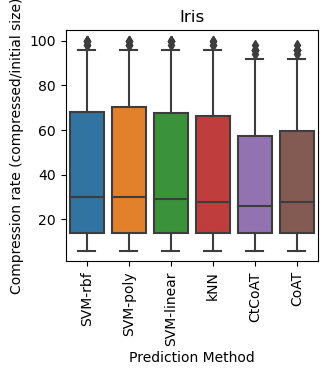

<Figure size 640x480 with 0 Axes>

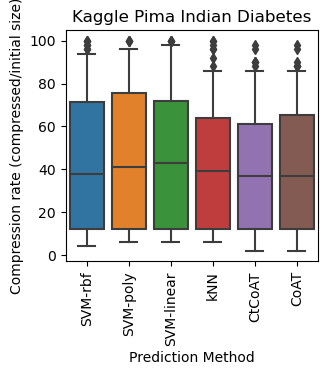

<Figure size 640x480 with 0 Axes>

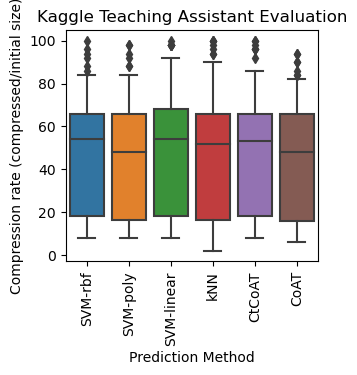

<Figure size 640x480 with 0 Axes>

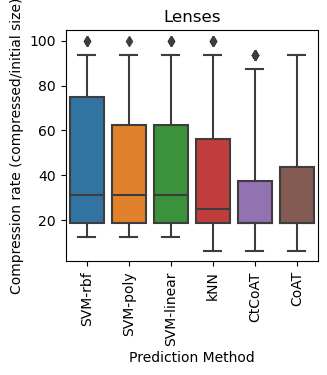

<Figure size 640x480 with 0 Axes>

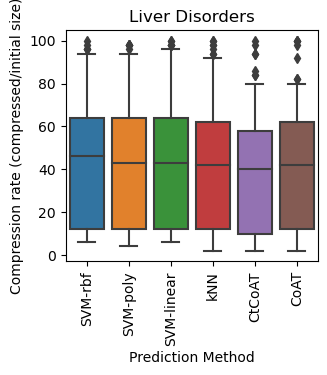

<Figure size 640x480 with 0 Axes>

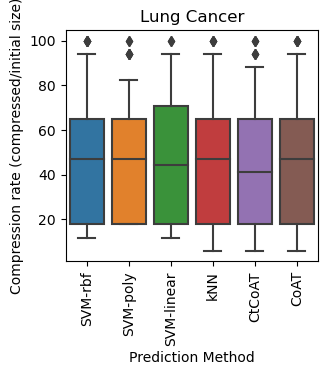

<Figure size 640x480 with 0 Axes>

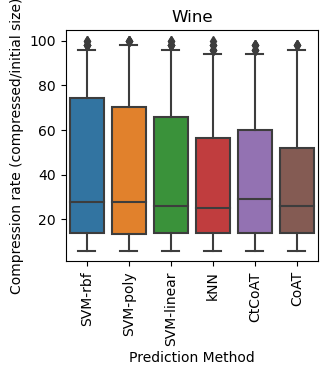

<Figure size 640x480 with 0 Axes>

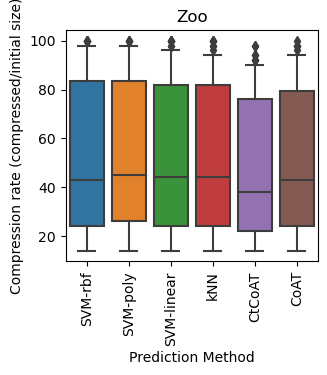

<Figure size 640x480 with 0 Axes>

In [23]:
for dataset in d["Dataset"].unique():
    plt.figure(figsize=(len(lv_2)*.25, 3))
    g = sns.boxplot(d[d["Dataset"]==dataset], x="level_1", y="compression_rate", whis=(0, 95), order=order1)
    g.set_ylabel("Compression rate (compressed/initial size)")
    g.set_xlabel("Prediction Method")
    g.set_xticklabels(g.get_xticklabels(), rotation=90)
    plt.title(dataset)
    plt.savefig(f"v0.2/plots/{dataset}/comp-VS-clf-all-maintainer.png", bbox_inches="tight")
    plt.show()
    plt.clf()